# Data Evaluation: User Study

## 0. Setup

In [117]:
import pandas as pd
import matplotlib as mpl
from scipy.stats import wilcoxon, mannwhitneyu, levene
import numpy as np
np.set_printoptions(legacy='1.25')
%matplotlib inline
import matplotlib.pyplot as plt

data_df = pd.read_csv('../ma-eval/combined-data.csv')
data_df

,participant,p_id,date,group,s_iss_miro,s_tp_miro,s_fp_miro,s_iss_pixie,s_tp_pixie,s_fp_pixie,...,UEQS-4,UEQS-5,UEQS-6,UEQS-7,UEQS-8,C-Q1,C-Q2,C-Q3,C-Q4,FQ2
0,1,MA12534,2026-06-29,AM,3,2,1,0,0,0,...,3,6,7,7,7,3,1,2,4,NaN
1,21,MA26593,2026-07-07,AM,1,1,0,0,0,0,...,3,5,6,7,6,3,4,4,4,NaN
2,13,MA34230,2026-07-01,AM,3,3,0,1,1,0,...,6,6,6,7,7,2,4,4,5,The locks need to be differentiable by look
3,5,MA7125,2026-06-30,AM,4,1,3,2,2,0,...,6,5,7,5,5,5,4,5,5,NaN
4,17,MA95137,2026-07-02,AM,2,2,0,0,0,0,...,2,7,7,6,5,5,4,4,5,It's nice to use but it takes some time to get...
5,9,MA95935,2026-06-30,AM,2,1,1,0,0,0,...,7,7,7,4,4,5,5,5,5,"Would have liked to have a ""total time needed ..."
6,15,MB10509,2026-07-02,BM,2,2,0,1,1,1,...,7,7,7,5,5,3,5,5,4,Tool did not make it clear which locks had whi...
7,7,MB24145,2026-06-30,BM,3,3,0,2,1,1,...,3,6,6,4,5,4,4,4,4,Please for gods sake put more contrast between...
8,23,MB41880,2026-07-07,BM,1,1,0,0,0,0,...,4,3,5,2,2,2,1,4,3,I feel like so much potential is wasted not in...
9,11,MB50964,2026-07-01,BM,2,2,0,4,2,2,...,5,7,7,6,6,4,4,4,5,i wasn't really sure what happened in the path...


## 1. Total Number of Answered Questions

### Total Numbers of Answered Questions

includes incorrect answers

In [81]:
total_counts_pacing = [
    'p_ans_miro',
    'p_ans_pixie',
]
correct_counts_pacing = [
    'p_right_miro',
    'p_right_pixie'
]
#num_data_df = data_df[num_data_cols]
#num_data_df.index = data_df['p_id']
#plot = num_data_df.plot.pie(subplots=True, figsize=(5, 5))

#### By Tool

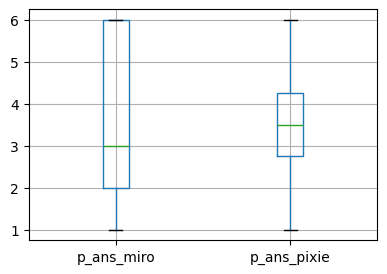

In [82]:
total_pacing_boxplot = data_df.boxplot(column=total_counts_pacing, figsize=(4.5, 3))

In [116]:
wilc_total_pacing = wilcoxon(data_df['p_ans_miro'], data_df['p_ans_pixie'])
wilc_total_pacing.statistic, wilc_total_pacing.pvalue

(96.5, 0.7473513186644183)

In [118]:
lev_total_pacing = levene(data_df['p_ans_miro'], data_df['p_ans_pixie'])
lev_total_pacing.statistic, lev_total_pacing.pvalue

(0.7353463587921849, 0.39560155462370694)

#### By Tool and Whiteboard Experience

In [153]:
data_exp_yes = data_df.loc[data_df['Whiteboard Experience Codified'] == 1]
data_exp_no = data_df.loc[data_df['Whiteboard Experience Codified'] == 0]

Text(0.5, 0.98, '')

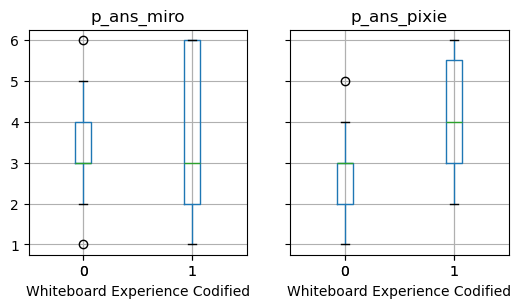

In [84]:
total_pacing_boxplot_by_wb_exp = data_df.boxplot(column=total_counts_pacing, by='Whiteboard Experience Codified', figsize=(6,3))
plt.suptitle('')

In [155]:
wilc_total_pacing_wb_exp = wilcoxon(data_exp_yes['p_ans_pixie'], data_exp_yes['p_ans_miro'], alternative='greater')
wilc_total_pacing_wb_exp.statistic, wilc_total_pacing_wb_exp.pvalue

(38.0, 0.325888948764388)

In [156]:
wilc_total_pacing_no_wb_exp = wilcoxon(data_exp_no['p_ans_pixie'], data_exp_no['p_ans_miro'], alternative='less')
wilc_total_pacing_no_wb_exp.statistic, wilc_total_pacing_no_wb_exp.pvalue

(15.0, 0.20703125)

*x*: answers in pixie *with* whiteboard experience
*y*: answers in pixie *without* whiteboard experience

$H_0$: the distribution underlying x is not stochastically greater than (i.e. is smaller than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically greater than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [ ]:


mwu_pixie_answers_wb_exp = mannwhitneyu(data_exp_yes['p_ans_pixie'], data_exp_no['p_ans_pixie'], alternative='greater')
mwu_pixie_answers_wb_exp.statistic, mwu_pixie_answers_wb_exp.pvalue

(103.5, 0.015198521622538362)

In [126]:
data_exp_yes['p_ans_pixie'].median()

4.0

In [125]:
data_exp_no['p_ans_pixie'].median()

3.0

#### By Tool and Miro Usage

In [148]:
data_usage_yes = data_df.loc[data_df['p_used_miro'] == 1]
data_usage_no = data_df.loc[data_df['p_used_miro'] == 0]

Text(0.5, 0.98, '')

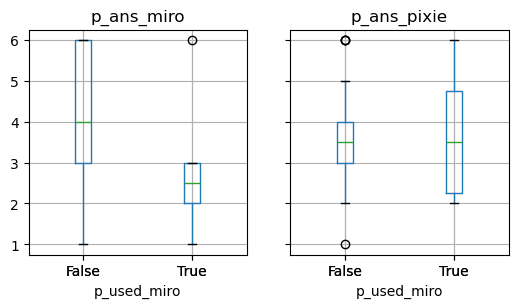

In [85]:
total_pacing_boxplot_by_miro_usage = data_df.boxplot(column=total_counts_pacing, by='p_used_miro', figsize=(6,3))
plt.suptitle('')

In [86]:
data_df[['Whiteboard Experience Codified', 'p_used_miro']].corr()

,Whiteboard Experience Codified,p_used_miro
Whiteboard Experience Codified,1.000000,0.447214
p_used_miro,0.447214,1.000000


In [151]:
wilc_total_pacing_by_miro_usage = wilcoxon(data_usage_yes['p_ans_pixie'], data_usage_yes['p_ans_miro'], alternative='greater')
wilc_total_pacing_by_miro_usage.statistic, wilc_total_pacing_by_miro_usage.pvalue

(11.0, 0.1875)

*x*: correct answers in Miro *with* Miro functionality usage

*y*: correct answers in Miro *without* Miro functionality usage

$H_0$: the distribution underlying x is not stochastically less than (i.e. is greater than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically less than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [ ]:
mwu_miro_total_miro_usage = mannwhitneyu(data_usage_yes['p_ans_miro'], data_usage_no['p_ans_miro'], alternative='less')
mwu_miro_total_miro_usage.statistic, mwu_miro_total_miro_usage.pvalue

(32.5, 0.07540184146884174)

In [146]:
data_usage_yes['p_ans_miro'].median()

2.5

In [147]:
data_usage_no['p_ans_miro'].median()

4.0

#### DIff Between Tools

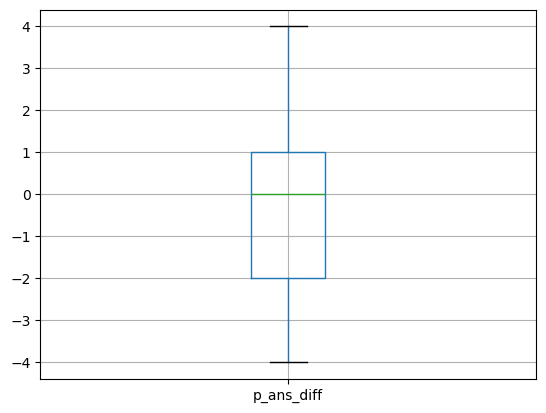

In [87]:
data_df['p_ans_diff'] = data_df['p_ans_pixie'] - data_df['p_ans_miro']
pacing_diff = data_df.boxplot(column=['p_ans_diff'])

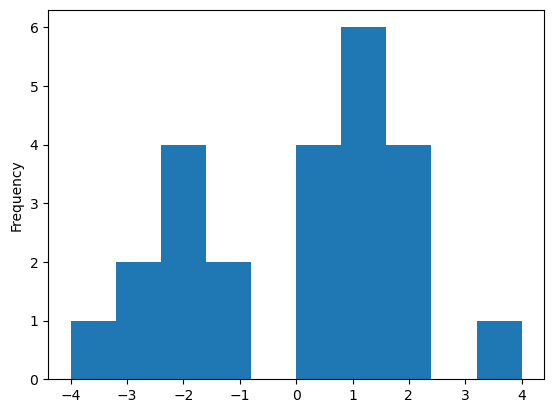

In [88]:
pacing_diff_hist = data_df['p_ans_diff'].plot.hist()

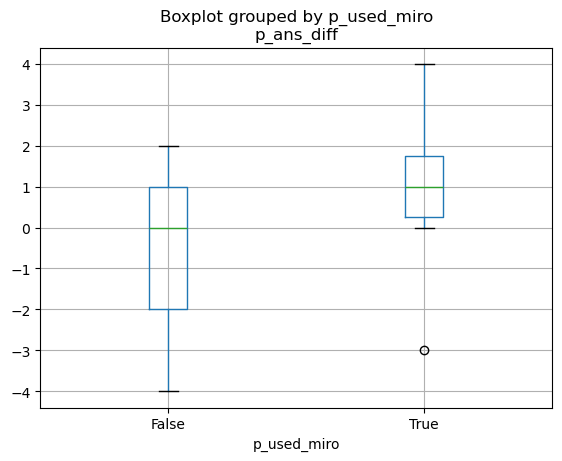

In [89]:
pacing_total_by_miro_usage = data_df.boxplot(column=['p_ans_diff'], by='p_used_miro')

#### Diff By Whiteboard Experience

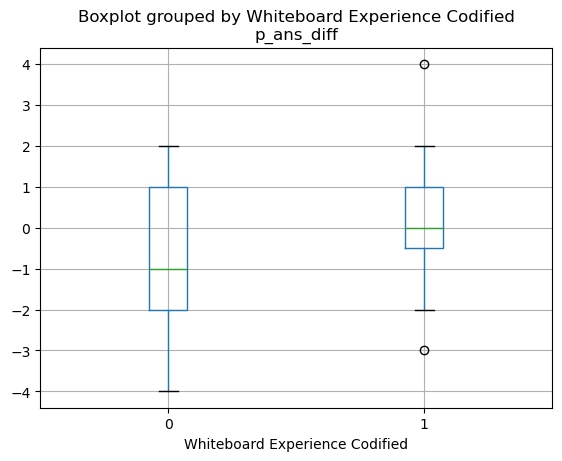

In [90]:
pacing_diff_by_wb_exp = data_df.boxplot(column=['p_ans_diff'], by="Whiteboard Experience Codified")

### Right Answers

#### By Tool

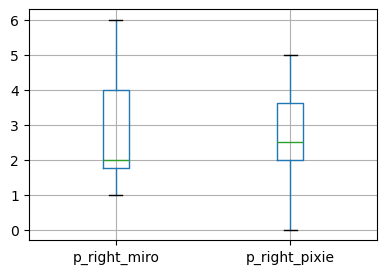

In [91]:
pacing_rights = data_df.boxplot(column=['p_right_miro', 'p_right_pixie'], figsize=(4.5, 3))

In [92]:
wilc_right_pacing = wilcoxon(data_df['p_right_miro'], data_df['p_right_pixie'])
wilc_right_pacing.statistic, wilc_right_pacing.pvalue

(98.5, 0.8058983773663436)

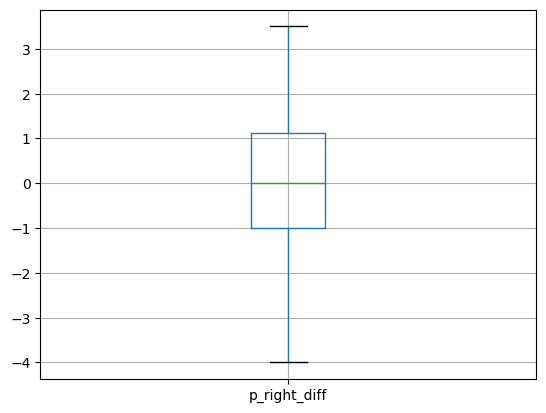

In [93]:
data_df['p_right_diff'] = data_df['p_right_pixie'] - data_df['p_right_miro']
pacing_right_diff = data_df.boxplot(column=['p_right_diff'])

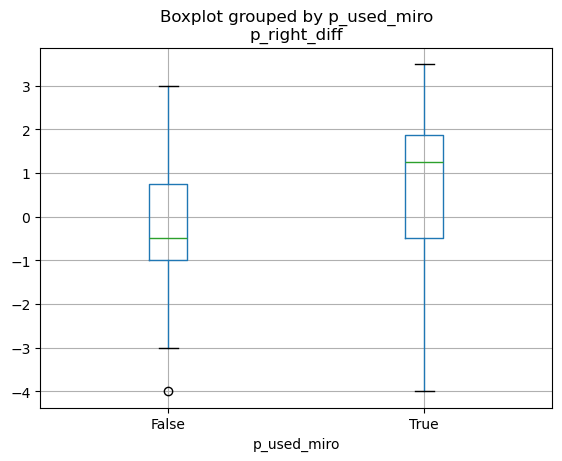

In [94]:
pacing_right_diff_by_miro_usage = data_df.boxplot(column=['p_right_diff'], by='p_used_miro')

In [95]:
data_df[['p_right_miro', 'p_right_pixie']].describe()

,p_right_miro,p_right_pixie
count,24.000000,24.000000
mean,2.791667,2.625000
std,1.718927,1.353337
min,1.000000,0.000000
25%,1.750000,2.000000
50%,2.000000,2.500000
75%,4.000000,3.625000
max,6.000000,5.000000


#### By Tool and Whiteboard Experience

In [130]:
data_exp_yes = data_df.loc[data_df['Whiteboard Experience Codified'] == 1]
data_exp_no = data_df.loc[data_df['Whiteboard Experience Codified'] == 0]

Text(0.5, 0.98, '')

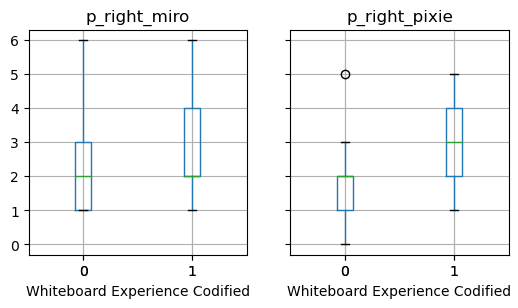

In [96]:
pacing_rights_by_wb_exp = data_df.boxplot(column=['p_right_miro', 'p_right_pixie'], by='Whiteboard Experience Codified', figsize=(6, 3))
plt.suptitle('')

In [131]:
wilc_right_pacing_wb_exp = wilcoxon(data_exp_yes['p_right_miro'], data_exp_yes['p_right_pixie'])
wilc_right_pacing_wb_exp.statistic, wilc_right_pacing_wb_exp.pvalue

(39.0, 0.6434989459129046)

In [ ]:
wilc_right_pacing_no_wb_exp = wilcoxon(data_exp_no['p_right_miro'], data_exp_no['p_right_pixie'])
wilc_right_pacing_no_wb_exp.statistic, wilc_right_pacing_wb_exp.pvalue

(19.0, 0.6434989459129046)

*x*: correct answers in pixie *with* whiteboard experience

*y*: acorrect nswers in pixie *without* whiteboard experience

$H_0$: the distribution underlying x is not stochastically greater than (i.e. is smaller than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically greater than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [ ]:
mwu_pixie_right_wb_exp = mannwhitneyu(data_exp_yes['p_right_pixie'], data_exp_no['p_right_pixie'], alternative='greater')
mwu_pixie_right_wb_exp.statistic, mwu_pixie_right_wb_exp.pvalue

(103.0, 0.01660439188879628)

In [128]:
data_exp_yes['p_right_pixie'].median()

3.0

In [129]:
data_exp_no['p_right_pixie'].median()

2.0

#### By Tool and Miro Usage

Text(0.5, 0.98, '')

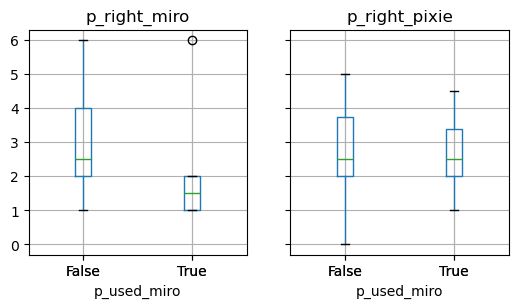

In [97]:
pacing_rights_by_miro_usage = data_df.boxplot(column=['p_right_miro', 'p_right_pixie'], by='p_used_miro', figsize=(6, 3))
plt.suptitle('')

In [152]:
wilc_right_pacing_by_miro_usage = wilcoxon(data_usage_yes['p_right_pixie'], data_usage_yes['p_right_miro'], alternative='greater')
wilc_right_pacing_by_miro_usage.statistic, wilc_right_pacing_by_miro_usage.pvalue

(13.5, 0.296875)

*x*: correct answers in Miro *with* Miro functionality usage

*y*: correct answers in Miro *without* Miro functionality usage

$H_0$: the distribution underlying x is not stochastically less than (i.e. is greater than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically less than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [144]:
data_usage_yes = data_df.loc[data_df['p_used_miro'] == 1]
data_usage_no = data_df.loc[data_df['p_used_miro'] == 0]

mwu_miro_right_miro_usage = mannwhitneyu(data_usage_yes['p_right_miro'], data_usage_no['p_right_miro'], alternative='less')
mwu_miro_right_miro_usage.statistic, mwu_miro_right_miro_usage.pvalue

(33.5, 0.08497339144083382)

In [139]:
data_usage_yes['p_right_miro'].median()

1.5

In [141]:
data_usage_no['p_right_miro'].median()

2.5

### Wrong Answers

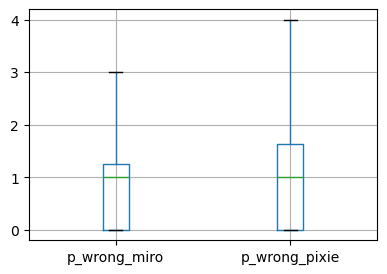

In [98]:
data_df['p_wrong_pixie'] = data_df['p_ans_pixie'] - data_df['p_right_pixie']
data_df['p_wrong_miro'] = data_df['p_ans_miro'] - data_df['p_right_miro']
pacing_wrongs = data_df.boxplot(column=['p_wrong_miro', 'p_wrong_pixie'], figsize=(4.5, 3))

In [99]:
wilc_wrong_pacing = wilcoxon(data_df['p_wrong_miro'], data_df['p_wrong_pixie'])
wilc_wrong_pacing.statistic, wilc_wrong_pacing.pvalue

(53.5, 0.7022608974564812)

In [100]:
data_df[['p_wrong_miro', 'p_wrong_pixie']].describe()

,p_wrong_miro,p_wrong_pixie
count,24.000000,24.000000
mean,0.916667,1.000000
std,0.974308,1.073394
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,1.250000,1.625000
max,3.000000,4.000000


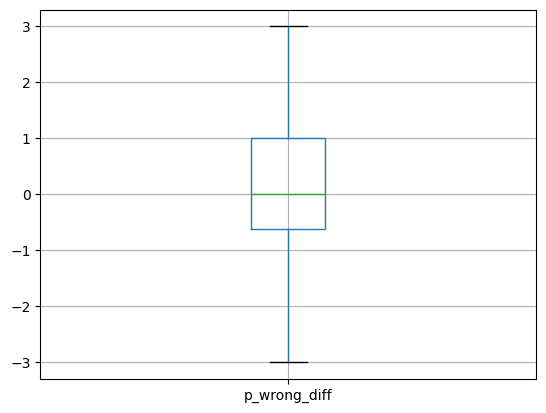

In [101]:
data_df['p_wrong_diff'] = data_df['p_wrong_pixie'] - data_df['p_wrong_miro']
pacing_wrongs = data_df.boxplot(column=['p_wrong_diff'])

In [102]:
data_df['p_wrong_diff'].describe()

count    24.000000
mean      0.083333
std       1.185663
min      -3.000000
25%      -0.625000
50%       0.000000
75%       1.000000
max       3.000000
Name: p_wrong_diff, dtype: float64

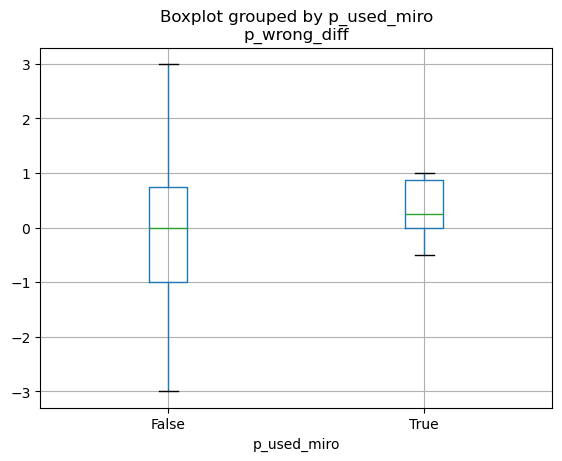

In [103]:
pacing_diff_by_miro_usage = data_df.boxplot(column=['p_wrong_diff'], by='p_used_miro')

Text(0.5, 0.98, '')

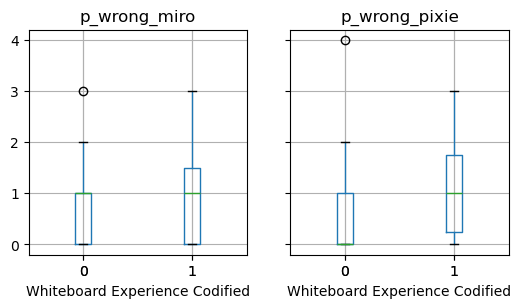

In [109]:
pacing_wrongs_by_wb_exp = data_df.boxplot(column=['p_wrong_miro', 'p_wrong_pixie'], by='Whiteboard Experience Codified', figsize=(6, 3))
plt.suptitle('')

Text(0.5, 0.98, '')

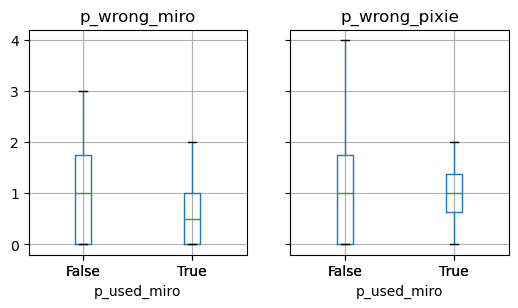

In [104]:
pacing_wrongs_by_miro_usage = data_df.boxplot(column=['p_wrong_miro', 'p_wrong_pixie'], by='p_used_miro', figsize=(6, 3))
plt.suptitle('')

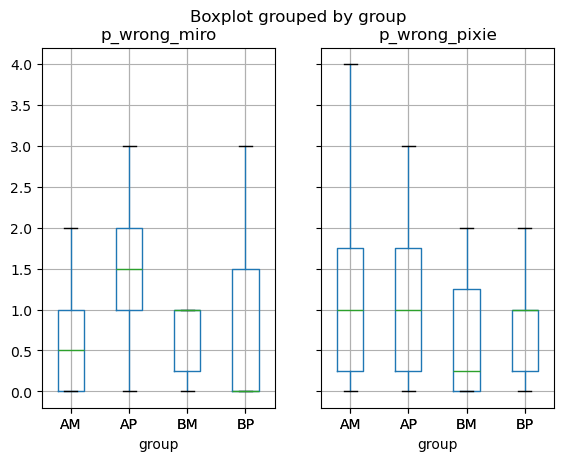

In [105]:
pacing_wrongs_grouped = data_df.boxplot(column=['p_wrong_miro', 'p_wrong_pixie'], by='group')

### Timeseries

In [106]:
timeseries_data_df = pd.read_csv('../ma-eval/time_series/all.csv')
timeseries_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
0,PA40344,AP,solvability_pixie,LA_3,01:27:30,STA,NaN,0
1,PA40344,AP,solvability_pixie,LA_3,01:27:44,OBS,pathfinding start-room after boss,14
2,PA40344,AP,solvability_pixie,LA_3,01:28:08,vb,ath blocked to boss,38
3,PA40344,AP,solvability_pixie,LA_3,01:28:45,OBS,successive pathfinding,75
4,PA40344,AP,solvability_pixie,LA_3,01:28:56,vb,oftlock 14,86
...,...,...,...,...,...,...,...,...
819,PA38184,AP,pacing_miro,LA_2,14:43:59,Q2A,R A takes longer than B,162
820,PA38184,AP,pacing_miro,LA_2,14:44:08,Q4A,R room 15,171
821,PA38184,AP,pacing_miro,LA_2,14:45:09,Q3A,"W no, B has more enemies than C",232
822,PA38184,AP,pacing_miro,LA_2,14:46:07,Q5A,? 21-2 to 21-3,290


#### Timeseries: Answers

In [107]:
answers_data_df = timeseries_data_df[timeseries_data_df['tag'].isin(['Q1A', 'Q2A', 'Q3A', 'Q4A', 'Q5A', 'Q6A'])]
answers_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
11,PA40344,AP,pacing_pixie,LA_1,01:43:52,Q1A,R not steadily increasing,41
12,PA40344,AP,pacing_pixie,LA_1,01:45:10,Q2A,R b shorter than a,119
13,PA40344,AP,pacing_pixie,LA_1,01:45:36,Q3A,W more enemies in b than c,145
14,PA40344,AP,pacing_pixie,LA_1,01:46:51,Q4A,W miniboss 18 or 7,220
15,PA40344,AP,pacing_pixie,LA_1,01:47:17,Q5A,W 9-3 to 5 sharpest increase,246
...,...,...,...,...,...,...,...,...
813,PA38184,AP,pacing_pixie,LA_1,14:37:13,Q2A,? same length,124
819,PA38184,AP,pacing_miro,LA_2,14:43:59,Q2A,R A takes longer than B,162
820,PA38184,AP,pacing_miro,LA_2,14:44:08,Q4A,R room 15,171
821,PA38184,AP,pacing_miro,LA_2,14:45:09,Q3A,"W no, B has more enemies than C",232


##### Distribution of Answer Events Across Time

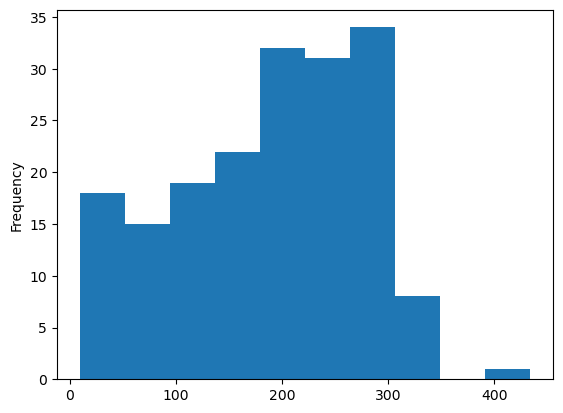

In [108]:
ax3 = answers_data_df['timedelta'].plot.hist()